# Channel Leave One Out Test

Notes:

* Only using 10 of the 30 ADL 
    * 11: "lift_suitcase_to_floor"
    * 12: "drink_from_glass"
    * 13: "answer_phone"
    * 16: "eat_apple"
    * 20: "use_key_unlock"
    * 21: "pour_water"
    * 23: "brush_teeth"
    * 24: "open_laptop"
    * 28: "open_door"
    * 29: "place_ball_in_basket"

## Imports

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib torch

import os, re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut

# Run the mvnx_file_reader.ipynb to load MVNX files
%run mvnx_file_reader.ipynb


Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Segment labels: ['Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head', 'RightShoulder', 'RightUpperArm', 'RightForeArm', 'RightHand', 'LeftShoulder', 'LeftUpperArm', 'LeftForeArm', 'LeftHand', 'RightUpperLeg', 'RightLowerLeg', 'RightFoot', 'RightToe', 'LeftUpperLeg', 'LeftLowerLeg', 'LeftFoot', 'LeftToe']
Segment IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
RightHand positions (first 5 frames): [[0.000326, -0.7332, 1.53858], [0.007659, -0.732989, 1.535369], [0.007659, -0.732989, 1.535369], [5.256316, 1.154359, 0.728047], [5.256684, 1.155001, 0.728414]]
normal
Data types: ['time', 'index', 'tc', 'ms', 'type', 'orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'contacts', 'sensorFreeAcceleration'

### Globals

In [2]:
# 10 ADL selection
TASK_TO_LABEL = { # U-Limb dataset has 30 total, we're only using 10 of them for this project
    11: "lift_suitcase_to_floor",
    12: "drink_from_glass",
    13: "answer_phone",
    16: "eat_apple",
    20: "use_key_unlock",
    21: "pour_water",
    23: "brush_teeth",
    24: "open_laptop",
    28: "open_door",
    29: "place_ball_in_basket",
}

ALLOWED_TASKS = set(TASK_TO_LABEL.keys())

LEFT_LIMB_SEGS  = ["LeftUpperArm", "LeftForeArm", "LeftHand", "LeftShoulder"]
RIGHT_LIMB_SEGS = ["RightUpperArm", "RightForeArm", "RightHand", "RightShoulder"]

def segments_for_tested_limb(limb: str):
    limb = str(limb).upper()
    return LEFT_LIMB_SEGS if limb == "L" else RIGHT_LIMB_SEGS

# You'll have to change the DATA_ROOT variable to point to where you have the data stored on your computer.
# The notebook should be in the same folder as the data, so a relative path should work.
DATA_ROOT = "ULF_in_ADL"
# DATA_ROOT = "D:/UZH_data/ULF_in_ADL"

CHANNELS = [
    "orientation",
    "position",
    "velocity",
    "acceleration",
    "angularVelocity",
    "angularAcceleration",
    "sensorFreeAcceleration",
    "sensorMagneticField",
    "sensorOrientation",
    "jointAngle",
    "jointAngleXZY",
]

WIN_LEN_S = 4.0  # seconds
STEP_S = 0.5     # seconds

# Sweep settings kept only for optional later use; they are not used by the single-run baseline cell.
SWEEP_WINDOW_LENGTHS = [WIN_LEN_S]
SWEEP_STEP_SIZES = [STEP_S]
MIN_OVERLAP_FRACTION = 0.50

# Cache settings
CACHE_DIR = "cached_datasets"
USE_DATASET_CACHE = True
FORCE_REBUILD_DATASET = False

# Result saving
RESULTS_DIR = "experiment_results"
RESULTS_BASENAME = "channel_ablation"

# Training settings
BATCH_SIZE_TRAIN = 128
BATCH_SIZE_EVAL = 256
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.2
KERNEL_SIZE = 5
TCN_CHANNELS = (64, 64, 128, 128)

# Early stopping
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 0.002
VAL_SIZE = 0.20
RANDOM_STATE = 42

# LOSO evaluation settings
LOSO_MAX_FOLDS = None  # Set to an integer like 4 for a quick pilot run, or keep None for all subjects
PLOT_FIRST_FOLD_CURVES = True
SAVE_PER_FOLD_CSV = True


### File Helpers

Helper functions to find files, parse task from filename, and extract per-segment vectors

In [3]:
# Helper functions to find and parse MVNX files
def iter_mvnx_files(root: str):
    for r, _, files in os.walk(root):
        for fn in files:
            if fn.lower().endswith(".mvnx"):
                yield os.path.join(r, fn)

# Parses participant, task, limb, and rep from filename
def parse_meta_from_filename(filepath: str):
    """
    Expected example: H01_T01_L1.mvnx OR P02_T15_R3.mvnx
    Returns dict: participant, task(int), limb('L'/'R'), rep(int)
    """
    base = os.path.basename(filepath)

    m = re.match(r"^(?P<participant>[A-Za-z]\d{2})_T(?P<task>\d{2})_(?P<limb>[LRlr])(?P<rep>\d)\.mvnx$", base)
    if not m:
        return None

    participant = m.group("participant")
    task = int(m.group("task"))
    limb = m.group("limb").upper()
    rep = int(m.group("rep"))
    return {"participant": participant, "task": task, "limb": limb, "rep": rep}


# Functions to extract frame rate and channel data from MVNX dicts
def get_frame_rate_hz(mvnx_dict) -> float:
    # MVNX stores it on subject
    fr = mvnx_dict["mvnx"]["subject"].get("frameRate", None)
    if fr is None:
        raise ValueError("frameRate not found in mvnx['mvnx']['subject']")
    return float(fr)

def _as_list(x):
    if isinstance(x, list):
        return x
    if x is None:
        return []
    return [x]

def build_segment_index_map(mvnx_dict):
    segments = _as_list(mvnx_dict["mvnx"]["subject"]["segments"]["segment"])
    return {seg["label"]: i for i, seg in enumerate(segments)}

def build_sensor_index_map(mvnx_dict):
    sensors = _as_list(mvnx_dict["mvnx"]["subject"]["sensors"]["sensor"])
    return {sensor["label"]: i for i, sensor in enumerate(sensors)}

def build_joint_index_map(mvnx_dict):
    joints = _as_list(mvnx_dict["mvnx"]["subject"]["joints"]["joint"])
    return {joint["label"]: i for i, joint in enumerate(joints)}

SEGMENT_CHANNEL_SPECS = {
    "orientation": (build_segment_index_map, 4),
    "position": (build_segment_index_map, 3),
    "velocity": (build_segment_index_map, 3),
    "acceleration": (build_segment_index_map, 3),
    "angularVelocity": (build_segment_index_map, 3),
    "angularAcceleration": (build_segment_index_map, 3),
}

SENSOR_CHANNEL_SPECS = {
    "sensorFreeAcceleration": (build_sensor_index_map, 3),
    "sensorMagneticField": (build_sensor_index_map, 3),
    "sensorOrientation": (build_sensor_index_map, 4),
}

# For joint channels we map each tested segment to the most relevant joint on that limb.
JOINT_CHANNEL_SPECS = {
    "jointAngle": 3,
    "jointAngleXZY": 3,
}

LEFT_SEGMENT_TO_JOINT = {
    "LeftShoulder": "jLeftT4Shoulder",
    "LeftUpperArm": "jLeftShoulder",
    "LeftForeArm": "jLeftElbow",
    "LeftHand": "jLeftWrist",
}

RIGHT_SEGMENT_TO_JOINT = {
    "RightShoulder": "jRightT4Shoulder",
    "RightUpperArm": "jRightShoulder",
    "RightForeArm": "jRightElbow",
    "RightHand": "jRightWrist",
}

def get_segment_joint_label(segment_label: str, limb: str) -> str:
    limb = str(limb).upper()
    mapping = LEFT_SEGMENT_TO_JOINT if limb == "L" else RIGHT_SEGMENT_TO_JOINT
    if segment_label not in mapping:
        raise KeyError(f"No joint mapping defined for segment '{segment_label}' on limb '{limb}'.")
    return mapping[segment_label]

def _slice_labeled_vector(mvnx_dict, frame_dict, channel: str, label: str, index_builder, components: int) -> np.ndarray:
    label_map = index_builder(mvnx_dict)
    if label not in label_map:
        raise KeyError(f"Label '{label}' not found for channel '{channel}'. Available labels include: {list(label_map)[:8]} ...")

    vec = frame_dict.get(channel, None)
    if vec is None:
        raise KeyError(f"Channel '{channel}' not found in this frame.")

    arr = np.asarray(vec, dtype=np.float32).ravel()
    idx = label_map[label]
    start = components * idx
    end = start + components

    if end > arr.size:
        raise ValueError(
            f"Channel '{channel}' with label '{label}' expected slice [{start}:{end}] "
            f"but frame only has {arr.size} values."
        )
    return arr[start:end]

def get_channel_vector(mvnx_dict, frame_dict, segment_label: str, channel: str, limb: str) -> np.ndarray:
    """
    Channel-aware extractor.

    Uses:
    - segment indexing for segment-level channels
    - sensor indexing for sensor-level channels
    - joint indexing for joint-angle channels
    """
    if channel in SEGMENT_CHANNEL_SPECS:
        index_builder, components = SEGMENT_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, segment_label, index_builder, components)

    if channel in SENSOR_CHANNEL_SPECS:
        index_builder, components = SENSOR_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, segment_label, index_builder, components)

    if channel in JOINT_CHANNEL_SPECS:
        joint_label = get_segment_joint_label(segment_label, limb)
        components = JOINT_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, joint_label, build_joint_index_map, components)

    raise KeyError(
        f"Unsupported channel '{channel}'. Add it to SEGMENT_CHANNEL_SPECS, "
        f"SENSOR_CHANNEL_SPECS, or JOINT_CHANNEL_SPECS."
    )

# Only keep frames where type="normal" (some files have "calibration" frames at the start that we want to ignore)
def only_normal_frames(mvnx: dict) -> list[dict]:
    frames = mvnx["mvnx"]["subject"]["frames"]["frame"]
    if isinstance(frames, dict):
        frames = [frames]
    return [fr for fr in frames if str(fr.get("type", "")).lower() == "normal"]

# Generator for start/end indices of sliding windows over N samples
def window_indices(n_samples: int, win_len: int, step: int):
    s = 0
    while s + win_len <= n_samples:
        yield s, s + win_len
        s += step


In [4]:
# quick test
sample_paths = list(iter_mvnx_files(DATA_ROOT))[:5]
print("Found files (sample):")
for p in sample_paths:
    print(" ", os.path.basename(p), parse_meta_from_filename(p))

Found files (sample):
  P17_T02_L3.mvnx {'participant': 'P17', 'task': 2, 'limb': 'L', 'rep': 3}
  P17_T24_L2.mvnx {'participant': 'P17', 'task': 24, 'limb': 'L', 'rep': 2}
  P17_T28_R3.mvnx {'participant': 'P17', 'task': 28, 'limb': 'R', 'rep': 3}
  P17_T26_L1.mvnx {'participant': 'P17', 'task': 26, 'limb': 'L', 'rep': 1}
  P17_T01_L3.mvnx {'participant': 'P17', 'task': 1, 'limb': 'L', 'rep': 3}


Helpers for mvnx frame/channel extractions

In [5]:
# Build windows for one file, returning X_win (num_windows, win_len, num_channels), y_win (num_windows,), g_win (num_windows,)
def windows_file_cnn(filepath: str, win_len_s, step_s, channels=None):

    if channels is None:
        channels = CHANNELS

    meta = parse_meta_from_filename(filepath)
    if meta is None or meta["task"] not in ALLOWED_TASKS:
        return None

    mvnx = load_mvnx(filepath)
    frames = only_normal_frames(mvnx)
    if len(frames) < 10:
        return None

    frame_rate = float(mvnx["mvnx"]["subject"].get("frameRate", 0))
    win_len = max(int(round(win_len_s * frame_rate)), 5)
    step = max(int(round(step_s * frame_rate)), 1)

    segments = segments_for_tested_limb(meta["limb"])
    N = len(frames)

    # Precompute channel arrays for each segment. The feature width depends on channel type:
    # xyz channels -> 3, quaternion channels -> 4.
    data = {}
    feature_dims = {}
    for seg in segments:
        for ch in channels:
            first_vec = get_channel_vector(mvnx, frames[0], seg, ch, meta["limb"])
            D = int(np.asarray(first_vec).size)
            arr = np.zeros((N, D), dtype=np.float32)
            arr[0] = first_vec
            for i in range(1, N):
                arr[i] = get_channel_vector(mvnx, frames[i], seg, ch, meta["limb"])
            data[(ch, seg)] = arr
            feature_dims[(ch, seg)] = D

    X_win, y_win, g_win = [], [], []
    for a, b in window_indices(N, win_len, step):
        cols = []
        for seg in segments:
            for ch in channels:
                cols.append(data[(ch, seg)][a:b])   # (T,D)
        Xw = np.concatenate(cols, axis=1)          # (T, C_total)
        X_win.append(Xw)
        y_win.append(TASK_TO_LABEL[meta["task"]])
        g_win.append(meta["participant"])

    if not X_win:
        return None

    return np.stack(X_win, axis=0), np.array(y_win), np.array(g_win)


## Building Dataset
Building a fixed post-window-study dataset for the all-channel baseline at 4.0 s window and 0.5 s step.


In [6]:
# Dataset caching helpers
def _safe_name(txt: str) -> str:
    txt = str(txt)
    txt = re.sub(r"[^A-Za-z0-9_.-]+", "-", txt)
    return txt.strip("-") or "default"

def make_dataset_cache_path(root: str, channels, win_len_s: float, step_s: float, allowed_tasks=None, cache_dir: str = CACHE_DIR):
    os.makedirs(cache_dir, exist_ok=True)

    root_name = _safe_name(os.path.basename(os.path.normpath(root)) or "dataset")
    channel_name = _safe_name("_".join(channels))
    task_name = "alltasks" if allowed_tasks is None else _safe_name("-".join(map(str, sorted(allowed_tasks))))

    filename = (
        f"dataset_{root_name}"
        f"__ch-{channel_name}"
        f"__win-{win_len_s:g}s"
        f"__step-{step_s:g}s"
        f"__tasks-{task_name}.npz"
    )
    return os.path.join(cache_dir, filename)

# Build the full dataset by iterating over all files and concatenating results
def build_dataset(root: str, win_len_s, step_s, channels=None):
    if channels is None:
        channels = CHANNELS

    X_list, y_list, g_list = [], [], []
    kept = 0
    skipped = 0

    for fp in iter_mvnx_files(root):
        meta = parse_meta_from_filename(fp)
        if meta is None:
            continue
        if meta["task"] not in ALLOWED_TASKS:
            continue

        try:
            out = windows_file_cnn(fp, win_len_s=win_len_s, step_s=step_s, channels=channels)
        except Exception as e:
            skipped += 1
            print(f"Skipping {os.path.basename(fp)} due to extraction/build error: {e}")
            continue

        if out is None:
            skipped += 1
            continue

        Xw, yw, gw = out
        X_list.append(Xw)
        y_list.append(yw)
        g_list.append(gw)
        kept += 1

    if not X_list:
        raise RuntimeError("No windows were built. Check parsing/task filters/DATA_ROOT.")

    X = np.concatenate(X_list, axis=0)   # (N, T, C)
    y = np.concatenate(y_list, axis=0)   # (N,)
    g = np.concatenate(g_list, axis=0)   # (N,)

    print(f"Kept files: {kept} | Skipped files (allowed but failed): {skipped}")
    print("X:", X.shape, "y:", y.shape, "groups:", g.shape)

    return X, y, g

def load_or_build_dataset(root: str, win_len_s, step_s, channels, use_cache=True, force_rebuild=False):
    cache_path = make_dataset_cache_path(
        root=root,
        channels=channels,
        win_len_s=win_len_s,
        step_s=step_s,
        allowed_tasks=ALLOWED_TASKS,
        cache_dir=CACHE_DIR,
    )

    if use_cache and os.path.exists(cache_path) and not force_rebuild:
        print(f"Loading cached dataset from: {cache_path}")
        cached = np.load(cache_path, allow_pickle=True)
        X = cached["X"]
        y = cached["y"]
        g = cached["groups"]
        return X, y, g, cache_path

    print("No cached dataset found. Building dataset from MVNX files...")
    X, y, g = build_dataset(root, win_len_s=win_len_s, step_s=step_s, channels=channels)

    if use_cache:
        np.savez_compressed(
            cache_path,
            X=X.astype(np.float32),
            y=y,
            groups=g,
            channels=np.array(channels, dtype=object),
            win_len_s=np.array([win_len_s], dtype=np.float32),
            step_s=np.array([step_s], dtype=np.float32),
        )
        print(f"Saved dataset cache to: {cache_path}")

    return X, y, g, cache_path

def summarize_dataset(X, y, groups, prefix="All-11-channel run"):
    print(f"{prefix} dataset loaded.")
    print("Dataset shape:", X.shape)
    print("Unique subjects:", len(set(groups)))
    vals, cnts = np.unique(y, return_counts=True)
    print("Class counts:", dict(zip(vals, cnts)))
    print("Example window shape (T,C):", X[0].shape)


### Normalization

Different normalization from SVM

In [7]:
# IMPORTANT:
# Do NOT normalize before LOSO splitting. That would let the held-out subject
# influence scaling. Instead, fit normalization on the training fold only and
# apply it to val/test inside each fold.

def fit_channel_zscore(X: np.ndarray, eps: float = 1e-8):
    """
    Fit one global z-score per feature channel using TRAINING WINDOWS ONLY.

    X: (N, T, C)
    Returns:
        mu: (C,)
        sd: (C,)
    """
    pooled = X.reshape(-1, X.shape[-1]).astype(np.float32)
    mu = pooled.mean(axis=0)
    sd = pooled.std(axis=0)
    sd = np.maximum(sd, eps)
    return mu, sd

def apply_channel_zscore(X: np.ndarray, mu: np.ndarray, sd: np.ndarray) -> np.ndarray:
    """Apply pre-fit channel-wise z-score to (N, T, C)."""
    return ((X.astype(np.float32) - mu) / sd).astype(np.float32)

print("Normalization helpers defined.")
print("Dataset arrays (X, y, groups) are loaded later inside run_windowing_study()")
print("via load_or_build_dataset(...), one window/step configuration at a time.")


Normalization helpers defined.
Dataset arrays (X, y, groups) are loaded later inside run_windowing_study()
via load_or_build_dataset(...), one window/step configuration at a time.


### Note on dataset creation and caching

This notebook runs a **leave-one-channel-out sweep** at a fixed **4.0 s** window and **0.5 s** step.

For each run, one channel is removed from the full 11-channel list, giving **11 runs total** with **10 channels each**.

The bottom cell calls:

- `run_channel_leave_one_out_sweep()`
- which repeatedly calls `load_or_build_dataset(...)`
- which either loads an existing `.npz` cache or builds the dataset from MVNX files
- then passes `X, y, groups` into `run_loso_experiment(...)`

So if you run a middle cell that tries to inspect `X` before the sweep cell has loaded
a dataset for that specific channel set, you will get a `NameError`.


## Train and Evaluate



Train/test split by subject and encode labels

In [8]:
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
import hashlib
from collections import defaultdict
from itertools import product
from datetime import datetime

def encode_labels(y: np.ndarray):
    labels = sorted(list(set(y)))
    lab2i = {lab:i for i, lab in enumerate(labels)}
    i2lab = {i:lab for lab,i in lab2i.items()}
    y_i = np.array([lab2i[v] for v in y], dtype=np.int64)
    return labels, lab2i, i2lab, y_i

def make_grouped_train_val_split(groups_train: np.ndarray, val_size: float = VAL_SIZE, random_state: int = RANDOM_STATE):
    """
    Creates a validation split using training subjects only.
    This is used INSIDE each LOSO fold for early stopping.
    """
    unique_subjects = np.unique(groups_train)

    if len(unique_subjects) < 2:
        raise ValueError("Need at least 2 training subjects to create a validation split.")

    if len(unique_subjects) == 2:
        # Fallback: keep one subject for train and one for validation
        val_subject = unique_subjects[-1]
        val_idx = np.where(groups_train == val_subject)[0]
        train_idx = np.where(groups_train != val_subject)[0]
        return train_idx, val_idx

    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    train_idx, val_idx = next(gss_val.split(np.zeros(len(groups_train)), groups=groups_train))
    return train_idx, val_idx

def hash_array(a: np.ndarray) -> str:
    h = hashlib.md5()
    h.update(a.tobytes())
    return h.hexdigest()

def report_split_integrity(name_a, X_a, g_a, idx_a, name_b, X_b, g_b, idx_b):
    overlap = set(g_a) & set(g_b)
    if overlap:
        print(f"WARNING: Subject(s) in both {name_a} and {name_b}: {overlap}")
    else:
        print(f"No subject overlap detected between {name_a} and {name_b}.")

    hashes_a = {hash_array(X_a[i]): idx_a[i] for i in range(len(X_a))}
    hashes_b = {hash_array(X_b[i]): idx_b[i] for i in range(len(X_b))}
    common = set(hashes_a.keys()) & set(hashes_b.keys())
    print(f"Identical windows in {name_a}/{name_b}: {len(common)}")
    if common:
        for h in list(common)[:5]:
            print(f"Example identical window - {name_a} idx: {hashes_a[h]} | {name_b} idx: {hashes_b[h]}")

def build_loso_splits(X, y_i, groups, max_folds=None):
    logo = LeaveOneGroupOut()
    all_loso_splits = list(logo.split(X, y_i, groups=groups))
    if max_folds is not None:
        all_loso_splits = all_loso_splits[:max_folds]
    return all_loso_splits

def window_overlap_fraction(win_len_s: float, step_s: float) -> float:
    return 1.0 - (step_s / win_len_s)

def is_valid_window_step_combo(win_len_s: float, step_s: float, min_overlap_fraction: float = MIN_OVERLAP_FRACTION) -> bool:
    if step_s <= 0 or win_len_s <= 0:
        return False
    if step_s > win_len_s:
        return False
    return window_overlap_fraction(win_len_s, step_s) >= min_overlap_fraction

def make_windowing_grid(window_lengths=None, step_sizes=None, min_overlap_fraction: float = MIN_OVERLAP_FRACTION):
    window_lengths = SWEEP_WINDOW_LENGTHS if window_lengths is None else window_lengths
    step_sizes = SWEEP_STEP_SIZES if step_sizes is None else step_sizes

    combos = []
    for win_len_s, step_s in product(window_lengths, step_sizes):
        overlap = window_overlap_fraction(win_len_s, step_s)
        if is_valid_window_step_combo(win_len_s, step_s, min_overlap_fraction=min_overlap_fraction):
            combos.append({
                "win_len_s": float(win_len_s),
                "step_s": float(step_s),
                "overlap_fraction": float(overlap),
            })
        else:
            print(f"Skipping invalid combo: win={win_len_s}, step={step_s}, overlap={overlap:.3f}")
    return combos

def ensure_results_dir(results_dir: str = RESULTS_DIR):
    os.makedirs(results_dir, exist_ok=True)
    return results_dir

def make_results_stem(study_name: str, win_len_s: float, step_s: float, results_dir: str = RESULTS_DIR):
    ensure_results_dir(results_dir)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    safe_study_name = _safe_name(study_name)

    base = f"{safe_study_name}__win-{win_len_s:g}s__step-{step_s:g}s__{timestamp}"

    # Keep filenames short enough for Windows path limits.
    max_base_len = 110
    if len(base) > max_base_len:
        name_hash = hashlib.md5(safe_study_name.encode("utf-8")).hexdigest()[:8]
        truncated = safe_study_name[:40].rstrip("-_.")
        base = f"{truncated}__{name_hash}__win-{win_len_s:g}s__step-{step_s:g}s__{timestamp}"

    if len(base) > max_base_len:
        name_hash = hashlib.md5(safe_study_name.encode("utf-8")).hexdigest()[:8]
        base = f"run__{name_hash}__w{win_len_s:g}s__s{step_s:g}s__{timestamp}"

    return os.path.join(results_dir, base)


Simple TCN dataset and model


In [9]:
import copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

class WindowDataset(Dataset):
    def __init__(self, X, y_int):
        # Convert (N, T, C) -> (N, C, T) for Conv1d
        self.X = torch.tensor(np.transpose(X, (0, 2, 1)), dtype=torch.float32)
        self.y = torch.tensor(y_int, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class Chomp1d(nn.Module):
    """
    Removes the extra right-side padding so the convolution is causal:
    output[t] depends only on x[:t].
    """
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation  # causal

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class SimpleTCN(nn.Module):
    def __init__(self, in_channels, n_classes, channels=TCN_CHANNELS, kernel_size=KERNEL_SIZE, dropout=DROPOUT):
        super().__init__()

        layers = []
        prev_channels = in_channels
        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_channels=prev_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
            prev_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(prev_channels, n_classes)

    def forward(self, x):
        z = self.tcn(x)
        z = self.pool(z).squeeze(-1)
        return self.classifier(z)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def make_loaders(X_train, y_train_i, X_val, y_val_i, X_test, y_test_i):
    train_ds = WindowDataset(X_train, y_train_i)
    val_ds   = WindowDataset(X_val, y_val_i)
    test_ds  = WindowDataset(X_test, y_test_i)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True, drop_last=False)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False, drop_last=False)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

def build_model_and_training_objects(in_channels: int, y_train_i: np.ndarray):
    model = SimpleTCN(
        in_channels=in_channels,
        n_classes=len(labels),
    ).to(device)

    counts = np.bincount(y_train_i, minlength=len(labels)).astype(np.float32)
    w = counts.sum() / (counts + 1e-6)
    w = w / w.mean()
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    return model, criterion, optimizer

def eval_model(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            ps.append(pred)
            ys.append(yb.numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred

def run_eval_loss_acc(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            pred = torch.argmax(logits, dim=1)
            ys.append(yb.cpu().numpy())
            ps.append(pred.cpu().numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc

print("TCN classes and helper functions are ready.")


Using device: cuda
TCN classes and helper functions are ready.


### Train and evaluate


####################################################################################################
RUNNING CHANNEL LEAVE-ONE-OUT SWEEP
Fixed window length: 4s
Fixed step size: 0.5s
Full channel list (11): ['orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY']

Channel LOO run 1/11
Left out: orientation
Using channels (10): ['position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 124) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-position_velocity_acceleration_angularVelocity_angularAcceleration_sensorFreeAcceleration_sensorMagneticField_se

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,9,0.697690,0.526221,0.567137
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,13,0.667990,0.868421,0.863809
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,16,0.710141,0.875878,0.831572
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.683262,0.978102,0.870123
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,13,0.690898,0.955432,0.907665
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,8,0.651191,0.846491,0.847637
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,9,0.617899,0.949868,0.937533
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,11,0.651802,0.830224,0.821451
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,9,0.590715,0.133431,0.062422
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,13,0.420703,0.686364,0.616423



LOSO SUMMARY
Overall window-level accuracy: 0.6573
Overall window-level macro F1: 0.6224
Mean fold accuracy: 0.6941 ± 0.2758
Mean fold macro F1: 0.6663 ± 0.2827

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,9,0.445150,0.980769,0.979704
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.683262,0.978102,0.870123
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,13,0.690898,0.955432,0.907665
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,9,0.617899,0.949868,0.937533
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,8,0.460094,0.933824,0.931514
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,8,0.439554,0.918033,0.901324
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,9,0.414122,0.894389,0.862218
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,16,0.710141,0.875878,0.831572
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,13,0.667990,0.868421,0.863809
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,20,0.463908,0.846922,0.788764



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.757     0.723     0.739       883
           brush_teeth      0.543     0.564     0.553      1313
      drink_from_glass      0.737     0.689     0.712      1148
             eat_apple      0.655     0.678     0.666       580
lift_suitcase_to_floor      0.633     0.675     0.653       917
             open_door      0.382     0.633     0.476       485
           open_laptop      0.822     0.604     0.697      2781
  place_ball_in_basket      0.338     0.679     0.451       467
            pour_water      0.831     0.688     0.753      4606
        use_key_unlock      0.431     0.665     0.523      1341

              accuracy                          0.657     14521
             macro avg      0.613     0.660     0.622     14521
          weighted avg      0.704     0.657     0.670     14521



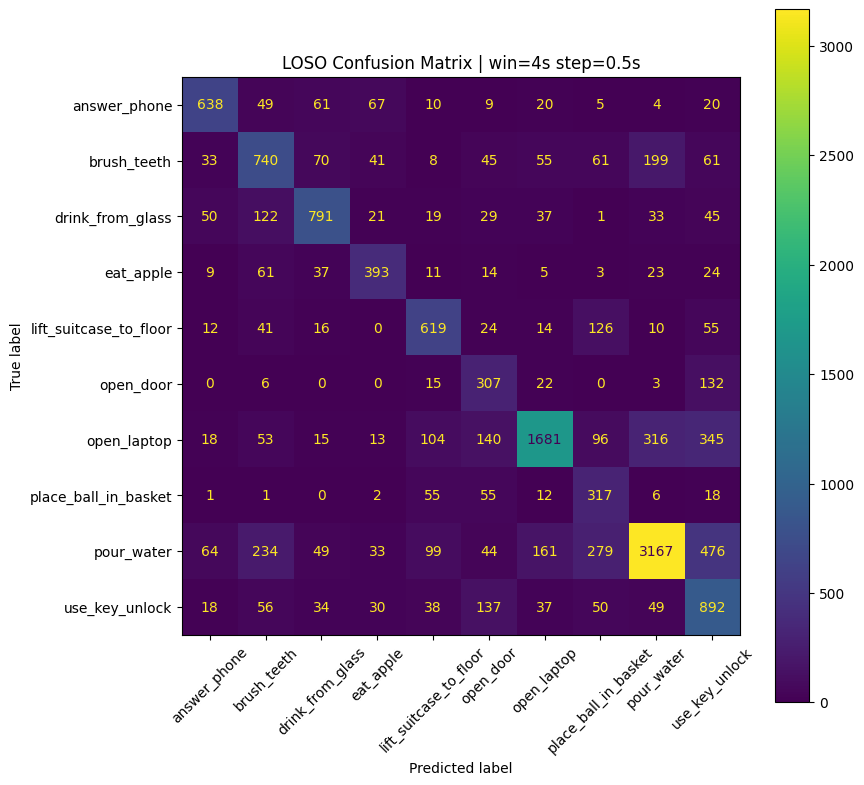

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-orientation__win-4s__step-0.5s__20260403_012214__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-orientation__win-4s__step-0.5s__20260403_012214__folds.csv

Channel LOO run 2/11
Left out: position
Using channels (10): ['orientation', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 128) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_velocity_acceleration_angularVelocity_angularAcceleration_sensorFreeAcceleration_sensorMagneticField_sensorOrientation_jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out position) dataset 

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,13,0.715434,0.636528,0.655400
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,15,0.704337,0.812030,0.767053
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,13,0.633476,0.929742,0.927175
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,14,0.686927,0.974453,0.938647
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,19,0.729994,0.935933,0.888018
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,11,0.708002,0.864035,0.878911
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,10,0.669517,0.981530,0.978671
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.725107,0.861940,0.876229
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.679291,0.287390,0.258450
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,12,0.554018,0.659091,0.581759



LOSO SUMMARY
Overall window-level accuracy: 0.6808
Overall window-level macro F1: 0.6792
Mean fold accuracy: 0.7126 ± 0.2477
Mean fold macro F1: 0.6960 ± 0.2588

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,10,0.669517,0.981530,0.978671
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,14,0.686927,0.974453,0.938647
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,10,0.590669,0.965164,0.947289
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,13,0.600059,0.963235,0.946351
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,8,0.547032,0.942308,0.924462
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,19,0.729994,0.935933,0.888018
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,13,0.633476,0.929742,0.927175
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,8,0.543427,0.895175,0.859533
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,11,0.708002,0.864035,0.878911
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.725107,0.861940,0.876229



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.890     0.751     0.814       883
           brush_teeth      0.615     0.511     0.558      1313
      drink_from_glass      0.798     0.752     0.774      1148
             eat_apple      0.771     0.690     0.728       580
lift_suitcase_to_floor      0.519     0.836     0.641       917
             open_door      0.616     0.705     0.658       485
           open_laptop      0.650     0.703     0.675      2781
  place_ball_in_basket      0.661     0.730     0.694       467
            pour_water      0.820     0.672     0.739      4606
        use_key_unlock      0.450     0.591     0.511      1341

              accuracy                          0.681     14521
             macro avg      0.679     0.694     0.679     14521
          weighted avg      0.705     0.681     0.686     14521



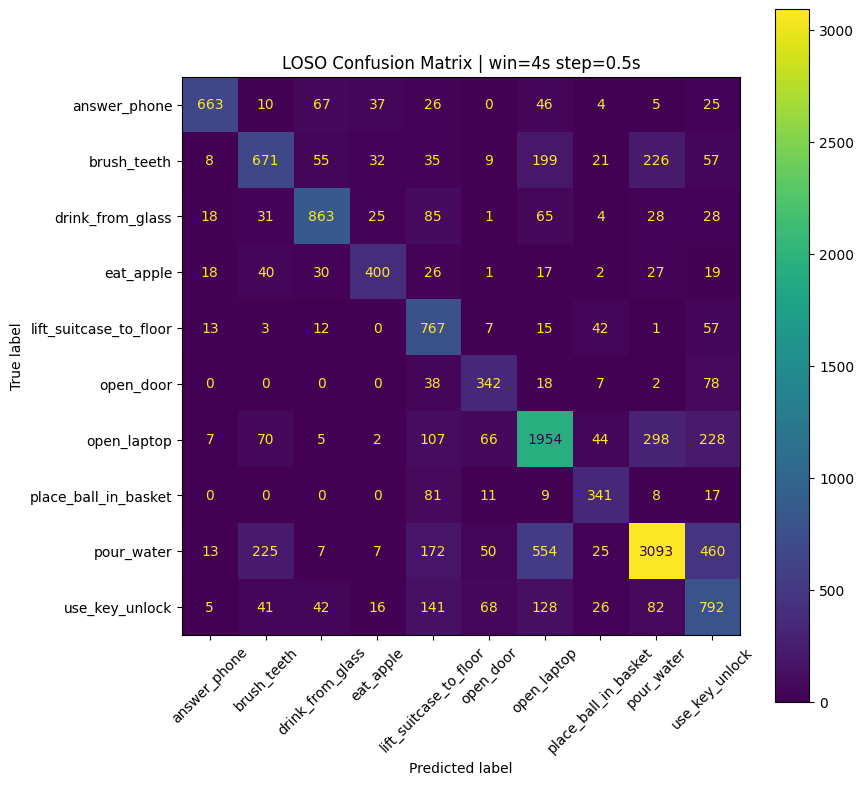

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-position__win-4s__step-0.5s__20260403_014930__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-position__win-4s__step-0.5s__20260403_014930__folds.csv

Channel LOO run 3/11
Left out: velocity
Using channels (10): ['orientation', 'position', 'acceleration', 'angularVelocity', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 128) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_position_acceleration_angularVelocity_angularAcceleration_sensorFreeAcceleration_sensorMagneticField_sensorOrientation_jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out velocity) dataset loaded

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,8,0.676264,0.479204,0.559030
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,17,0.651802,0.766917,0.686955
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.632254,0.864169,0.818358
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,10,0.635614,0.937956,0.809282
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,9,0.618815,0.682451,0.779530
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,8,0.567807,0.902047,0.893918
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,17,0.623091,0.957784,0.942429
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,10,0.639585,0.891791,0.887763
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,10,0.632254,0.129032,0.070371
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,17,0.422831,0.648864,0.571926



LOSO SUMMARY
Overall window-level accuracy: 0.6078
Overall window-level macro F1: 0.5771
Mean fold accuracy: 0.6422 ± 0.2755
Mean fold macro F1: 0.6342 ± 0.2854

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,9,0.466256,0.973039,0.950912
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,17,0.623091,0.957784,0.942429
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,10,0.635614,0.937956,0.809282
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,8,0.567807,0.902047,0.893918
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,7,0.468310,0.895175,0.865162
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,10,0.639585,0.891791,0.887763
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.632254,0.864169,0.818358
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,7,0.376741,0.829327,0.869930
22,23,P28,4.0,0.5,0.875,10051,3408,1062,19,5,8,0.499120,0.820151,0.795446
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,8,0.419601,0.772541,0.884167



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.652     0.685     0.668       883
           brush_teeth      0.629     0.502     0.558      1313
      drink_from_glass      0.533     0.674     0.596      1148
             eat_apple      0.493     0.703     0.580       580
lift_suitcase_to_floor      0.671     0.685     0.678       917
             open_door      0.373     0.685     0.483       485
           open_laptop      0.805     0.548     0.652      2781
  place_ball_in_basket      0.234     0.679     0.348       467
            pour_water      0.770     0.614     0.683      4606
        use_key_unlock      0.492     0.561     0.524      1341

              accuracy                          0.608     14521
             macro avg      0.565     0.634     0.577     14521
          weighted avg      0.665     0.608     0.622     14521



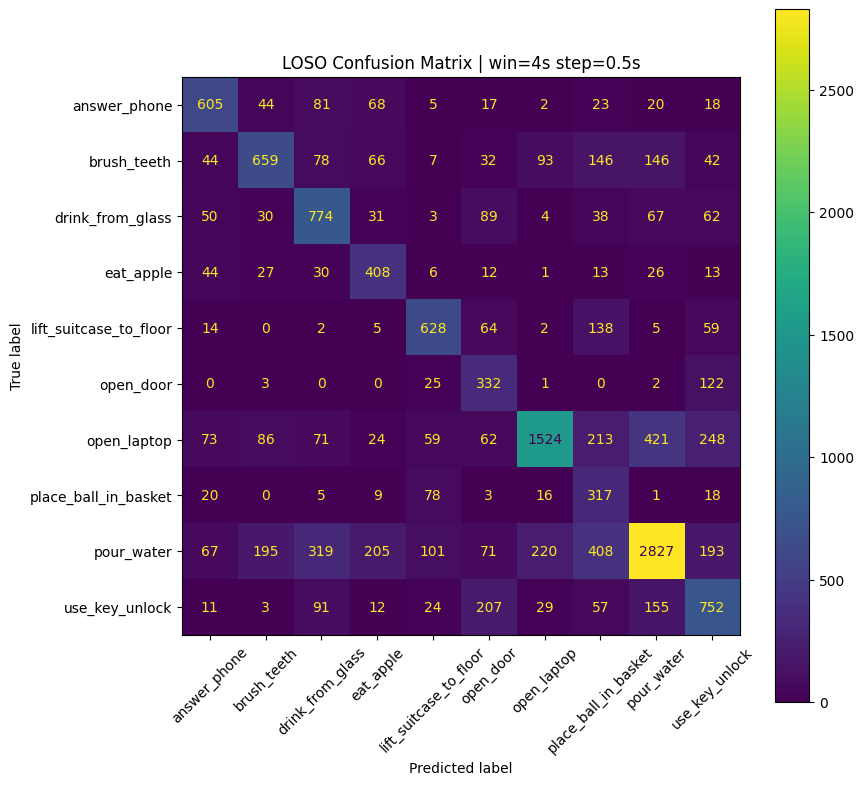

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-velocity__win-4s__step-0.5s__20260403_021507__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-velocity__win-4s__step-0.5s__20260403_021507__folds.csv

Channel LOO run 4/11
Left out: acceleration
Using channels (10): ['orientation', 'position', 'velocity', 'angularVelocity', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 128) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_position_velocity_angularVelocity_angularAcceleration_sensorFreeAcceleration_sensorMagneticField_sensorOrientation_jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out acceleration) dataset loaded

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,14,0.648812,0.555154,0.576914
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,9,0.662798,0.815789,0.865914
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.674710,0.911007,0.884589
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.612401,0.945255,0.803295
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,13,0.666158,0.866295,0.892330
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,14,0.619120,0.840643,0.871243
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.588271,0.899736,0.880813
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.571778,0.906716,0.900725
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.652413,0.145161,0.060376
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,7,0.369345,0.660227,0.608988



LOSO SUMMARY
Overall window-level accuracy: 0.6398
Overall window-level macro F1: 0.6257
Mean fold accuracy: 0.6760 ± 0.2633
Mean fold macro F1: 0.6679 ± 0.2595

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,7,0.415786,0.953431,0.954187
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.612401,0.945255,0.803295
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,8,0.516725,0.926230,0.932270
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.674710,0.911007,0.884589
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.571778,0.906716,0.900725
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.588271,0.899736,0.880813
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,11,0.364769,0.891827,0.840679
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,13,0.467723,0.868552,0.798214
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,13,0.666158,0.866295,0.892330
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,14,0.619120,0.840643,0.871243



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.790     0.698     0.741       883
           brush_teeth      0.503     0.540     0.521      1313
      drink_from_glass      0.638     0.706     0.670      1148
             eat_apple      0.647     0.647     0.647       580
lift_suitcase_to_floor      0.908     0.680     0.778       917
             open_door      0.371     0.722     0.490       485
           open_laptop      0.595     0.631     0.613      2781
  place_ball_in_basket      0.434     0.707     0.537       467
            pour_water      0.819     0.637     0.717      4606
        use_key_unlock      0.505     0.588     0.544      1341

              accuracy                          0.640     14521
             macro avg      0.621     0.655     0.626     14521
          weighted avg      0.674     0.640     0.649     14521



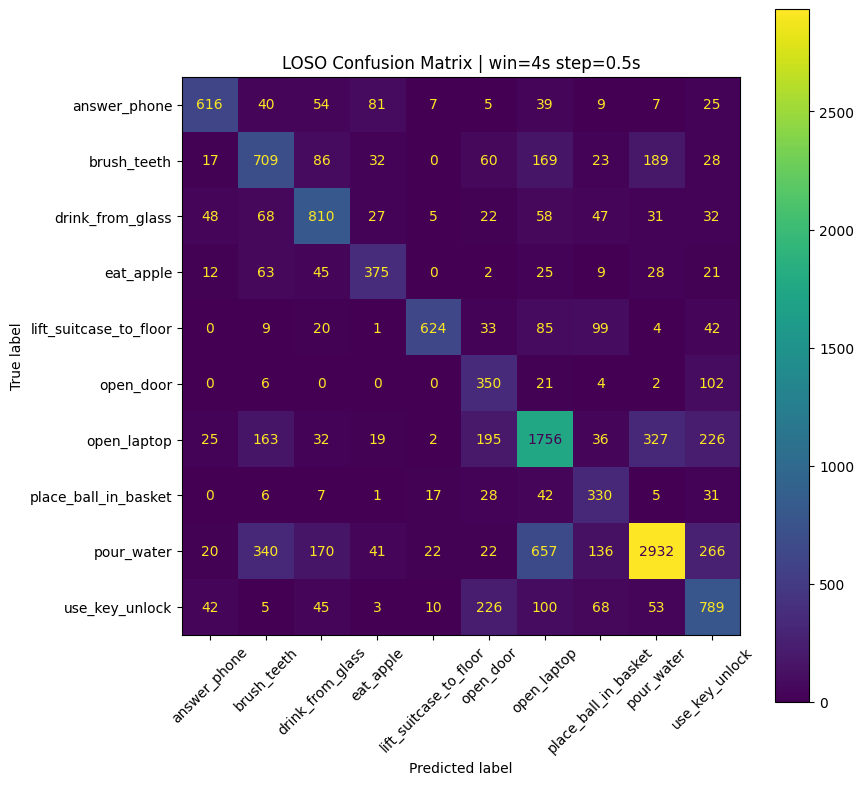

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-acceleration__win-4s__step-0.5s__20260403_024243__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-acceleration__win-4s__step-0.5s__20260403_024243__folds.csv

Channel LOO run 5/11
Left out: angularVelocity
Using channels (10): ['orientation', 'position', 'velocity', 'acceleration', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 128) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_position_velocity_acceleration_angularAcceleration_sensorFreeAcceleration_sensorMagneticField_sensorOrientation_jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out angularVelocity) datase

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,10,0.688651,0.618445,0.627665
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,10,0.667074,0.774436,0.668436
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,13,0.538485,0.896956,0.840751
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.615761,0.937956,0.866994
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,11,0.693341,0.860724,0.868117
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,10,0.614539,0.921053,0.924872
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,15,0.509469,0.891821,0.893662
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.579414,0.830224,0.819796
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,7,0.637752,0.102639,0.049330
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,13,0.420969,0.632955,0.628568



LOSO SUMMARY
Overall window-level accuracy: 0.6298
Overall window-level macro F1: 0.6093
Mean fold accuracy: 0.6693 ± 0.2604
Mean fold macro F1: 0.6402 ± 0.2742

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,8,0.496185,0.980392,0.975891
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.615761,0.937956,0.866994
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,13,0.417254,0.928279,0.881777
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,10,0.614539,0.921053,0.924872
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,13,0.538485,0.896956,0.840751
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,15,0.509469,0.891821,0.893662
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,9,0.513791,0.873544,0.826049
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,10,0.420718,0.872596,0.918460
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,11,0.693341,0.860724,0.868117
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.579414,0.830224,0.819796



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.835     0.659     0.737       883
           brush_teeth      0.648     0.519     0.577      1313
      drink_from_glass      0.601     0.680     0.638      1148
             eat_apple      0.488     0.653     0.559       580
lift_suitcase_to_floor      0.535     0.759     0.628       917
             open_door      0.246     0.639     0.355       485
           open_laptop      0.670     0.629     0.649      2781
  place_ball_in_basket      0.723     0.677     0.699       467
            pour_water      0.801     0.621     0.700      4606
        use_key_unlock      0.523     0.588     0.553      1341

              accuracy                          0.630     14521
             macro avg      0.607     0.643     0.609     14521
          weighted avg      0.672     0.630     0.641     14521



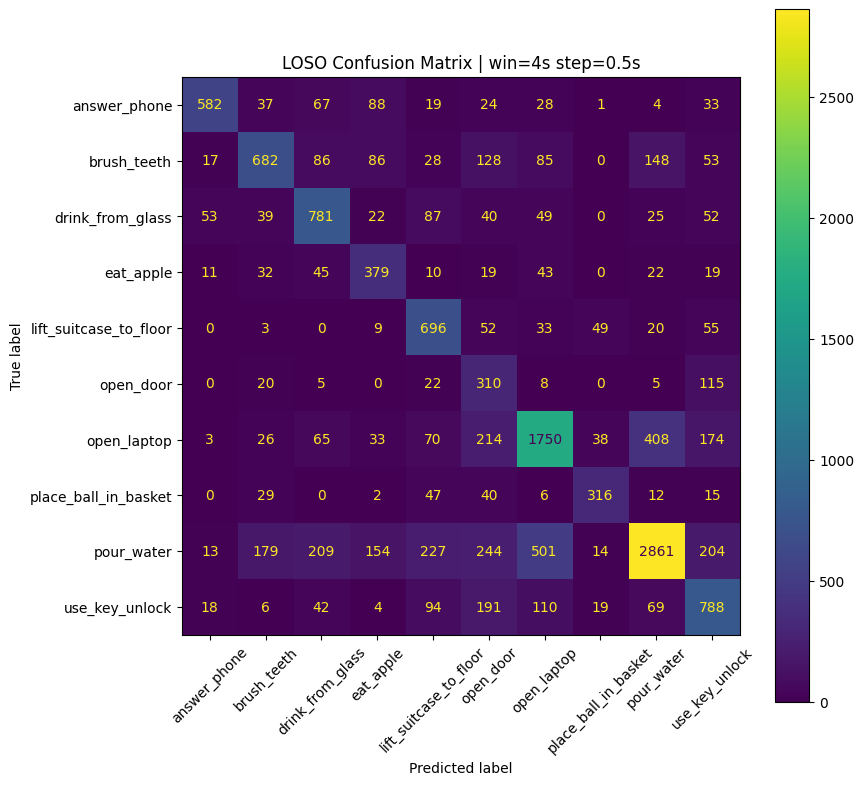

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-angularVelocity__win-4s__step-0.5s__20260403_030816__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-angularVelocity__win-4s__step-0.5s__20260403_030816__folds.csv

Channel LOO run 6/11
Left out: angularAcceleration
Using channels (10): ['orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 128) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_position_velocity_acceleration_angularVelocity_sensorFreeAcceleration_sensorMagneticField_sensorOrientation_jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out angularAcceleration) 

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,12,0.711751,0.567812,0.538020
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,12,0.680819,0.751880,0.782985
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.635614,0.843091,0.803090
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,12,0.678986,0.963504,0.820360
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,7,0.708002,0.805014,0.804898
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,9,0.658522,0.875731,0.876881
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,13,0.648748,0.883905,0.889411
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,12,0.705864,0.914179,0.905620
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,9,0.596213,0.200147,0.122830
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,15,0.401277,0.704545,0.647407



LOSO SUMMARY
Overall window-level accuracy: 0.6565
Overall window-level macro F1: 0.6421
Mean fold accuracy: 0.6847 ± 0.2638
Mean fold macro F1: 0.6720 ± 0.2526

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,12,0.678986,0.963504,0.820360
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,17,0.532277,0.955882,0.910642
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,14,0.403372,0.954327,0.962305
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,12,0.705864,0.914179,0.905620
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,9,0.471538,0.909836,0.872185
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,11,0.467723,0.900166,0.874168
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,13,0.648748,0.883905,0.889411
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,9,0.658522,0.875731,0.876881
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.635614,0.843091,0.803090
13,14,P12,4.0,0.5,0.875,9687,4093,741,19,5,7,0.423894,0.825911,0.744522



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.795     0.718     0.755       883
           brush_teeth      0.408     0.636     0.497      1313
      drink_from_glass      0.618     0.726     0.668      1148
             eat_apple      0.503     0.628     0.558       580
lift_suitcase_to_floor      0.891     0.667     0.763       917
             open_door      0.743     0.608     0.669       485
           open_laptop      0.790     0.668     0.724      2781
  place_ball_in_basket      0.448     0.730     0.555       467
            pour_water      0.840     0.637     0.725      4606
        use_key_unlock      0.431     0.616     0.507      1341

              accuracy                          0.656     14521
             macro avg      0.647     0.663     0.642     14521
          weighted avg      0.707     0.656     0.670     14521



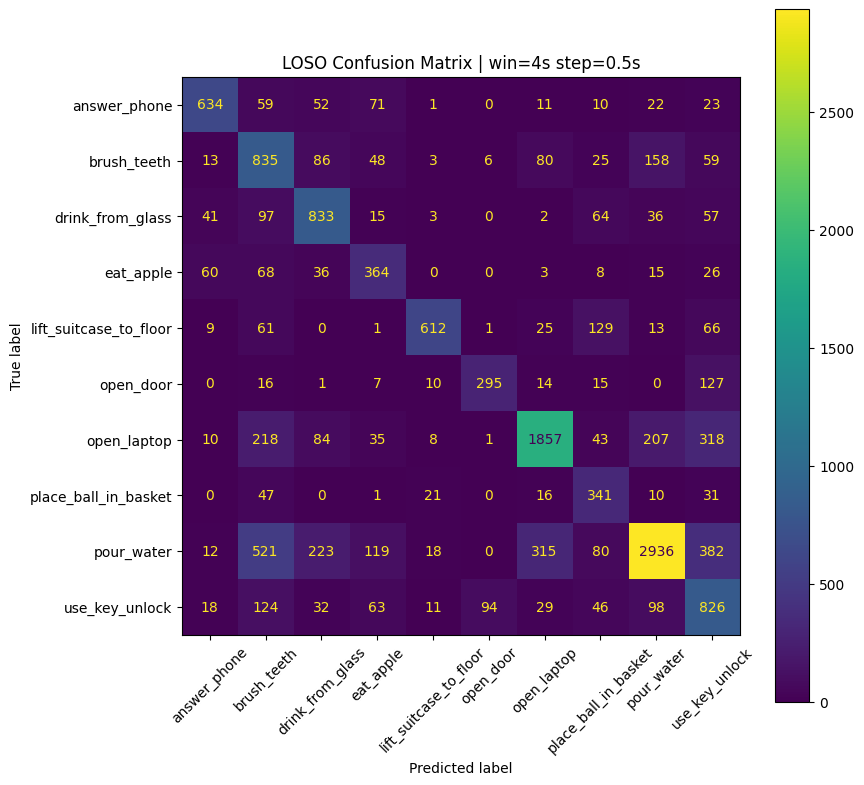

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-angularAcceleration__win-4s__step-0.5s__20260403_033447__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-angularAcceleration__win-4s__step-0.5s__20260403_033447__folds.csv

Channel LOO run 7/11
Left out: sensorFreeAcceleration
Using channels (10): ['orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 128) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_position_velocity_acceleration_angularVelocity_angularAcceleration_sensorMagneticField_sensorOrientation_jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out sensorFreeAccele

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,9,0.696016,0.734177,0.697207
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,8,0.639585,0.827068,0.713103
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.629505,0.906323,0.862171
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,11,0.699756,0.952555,0.813645
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,9,0.650275,0.885794,0.856295
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,10,0.653940,0.875731,0.874594
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.661881,0.970976,0.942893
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,13,0.645082,0.904851,0.861291
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,8,0.635308,0.158358,0.045568
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,8,0.407398,0.751136,0.706157



LOSO SUMMARY
Overall window-level accuracy: 0.6475
Overall window-level macro F1: 0.6276
Mean fold accuracy: 0.6824 ± 0.2612
Mean fold macro F1: 0.6551 ± 0.2805

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.661881,0.970976,0.942893
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,11,0.699756,0.952555,0.813645
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,8,0.453932,0.946078,0.935451
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.629505,0.906323,0.862171
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,13,0.645082,0.904851,0.861291
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,15,0.431468,0.903846,0.920574
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,9,0.650275,0.885794,0.856295
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,7,0.439847,0.878536,0.820294
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,10,0.653940,0.875731,0.874594
22,23,P28,4.0,0.5,0.875,10051,3408,1062,19,5,12,0.518486,0.831450,0.813967



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.890     0.687     0.776       883
           brush_teeth      0.517     0.568     0.542      1313
      drink_from_glass      0.735     0.720     0.727      1148
             eat_apple      0.548     0.688     0.610       580
lift_suitcase_to_floor      0.701     0.747     0.723       917
             open_door      0.310     0.726     0.434       485
           open_laptop      0.653     0.663     0.658      2781
  place_ball_in_basket      0.607     0.563     0.584       467
            pour_water      0.836     0.636     0.722      4606
        use_key_unlock      0.450     0.562     0.500      1341

              accuracy                          0.648     14521
             macro avg      0.625     0.656     0.628     14521
          weighted avg      0.687     0.648     0.658     14521



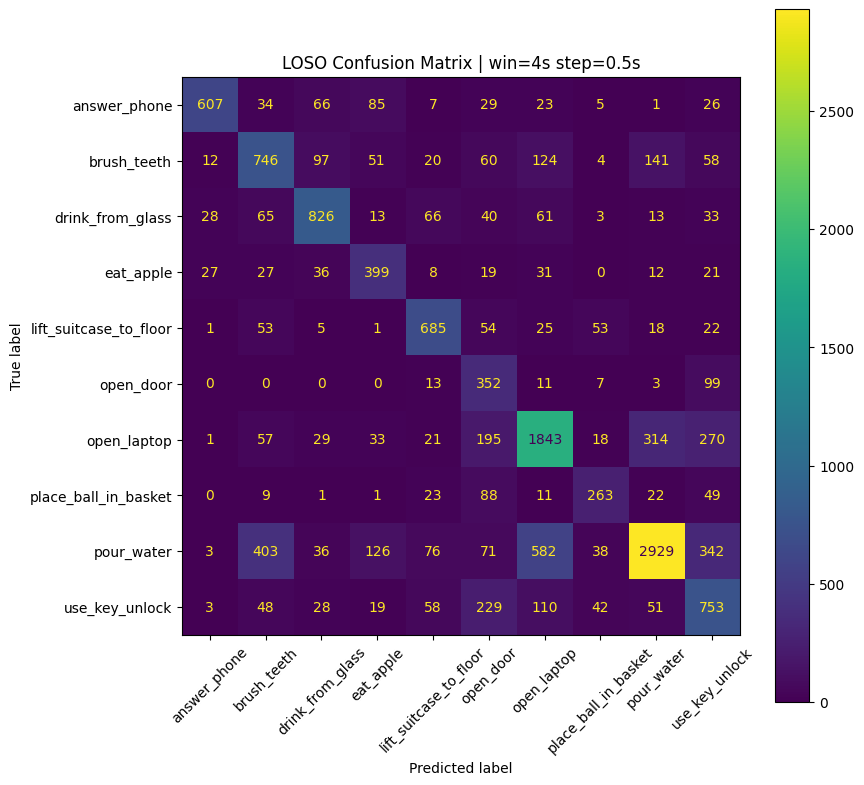

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-sensorFreeAcceleration__win-4s__step-0.5s__20260403_040054__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-sensorFreeAcceleration__win-4s__step-0.5s__20260403_040054__folds.csv

Channel LOO run 8/11
Left out: sensorMagneticField
Using channels (10): ['orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorOrientation', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 128) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_position_velocity_acceleration_angularVelocity_angularAcceleration_sensorFreeAcceleration_sensorOrientation_jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out sensorM

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,9,0.662538,0.603978,0.622637
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,12,0.650275,0.860902,0.838179
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,13,0.642028,0.920375,0.911196
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.695174,0.941606,0.801511
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,19,0.653940,0.760446,0.811301
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,12,0.676848,0.881579,0.888753
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,12,0.686622,0.949868,0.945470
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,10,0.592853,0.847015,0.817374
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,8,0.594685,0.189150,0.078672
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,20,0.449973,0.382955,0.351738



LOSO SUMMARY
Overall window-level accuracy: 0.6496
Overall window-level macro F1: 0.6317
Mean fold accuracy: 0.6956 ± 0.2481
Mean fold macro F1: 0.6667 ± 0.2526

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,9,0.500880,0.985294,0.972915
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,12,0.686622,0.949868,0.945470
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.695174,0.941606,0.801511
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,9,0.438554,0.935096,0.933804
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,13,0.642028,0.920375,0.911196
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,9,0.492958,0.903494,0.883446
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,12,0.676848,0.881579,0.888753
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,12,0.650275,0.860902,0.838179
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,6,0.397300,0.850410,0.808704
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,10,0.592853,0.847015,0.817374



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.910     0.650     0.758       883
           brush_teeth      0.645     0.564     0.602      1313
      drink_from_glass      0.601     0.651     0.625      1148
             eat_apple      0.667     0.690     0.678       580
lift_suitcase_to_floor      0.615     0.716     0.662       917
             open_door      0.469     0.614     0.532       485
           open_laptop      0.591     0.653     0.620      2781
  place_ball_in_basket      0.500     0.642     0.562       467
            pour_water      0.820     0.660     0.731      4606
        use_key_unlock      0.475     0.644     0.547      1341

              accuracy                          0.650     14521
             macro avg      0.629     0.648     0.632     14521
          weighted avg      0.676     0.650     0.656     14521



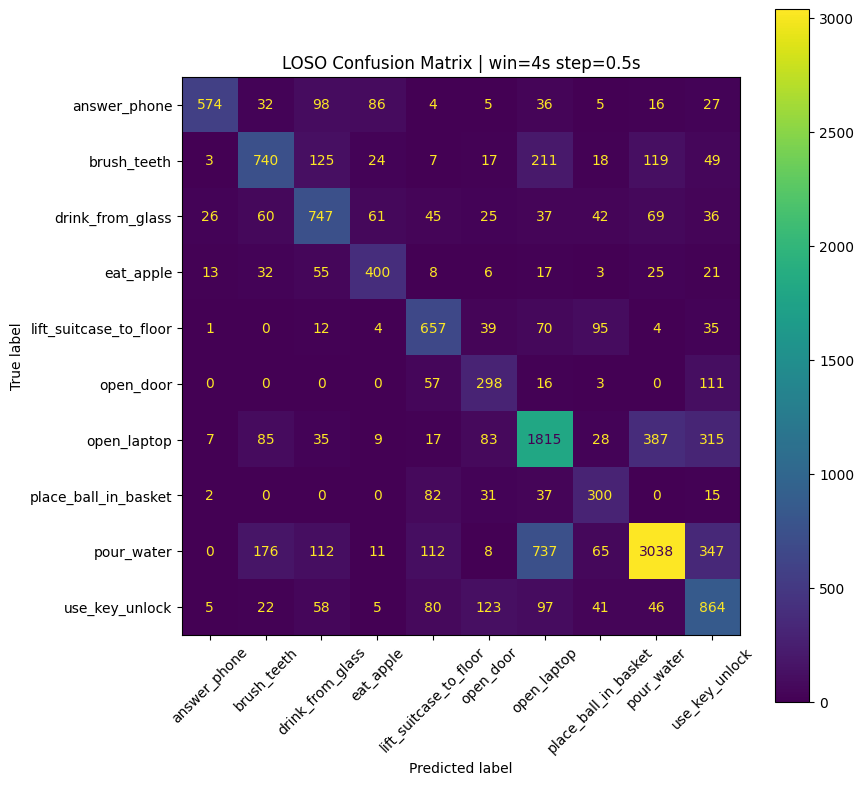

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-sensorMagneticField__win-4s__step-0.5s__20260403_042654__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-sensorMagneticField__win-4s__step-0.5s__20260403_042654__folds.csv

Channel LOO run 9/11
Left out: sensorOrientation
Using channels (10): ['orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorMagneticField', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 124) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_position_velocity_acceleration_angularVelocity_angularAcceleration_sensorFreeAcceleration_sensorMagneticField_jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out sensorOrien

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,10,0.717442,0.638336,0.656358
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,16,0.621258,0.921053,0.949266
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,10,0.618509,0.873536,0.851882
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.604154,0.930657,0.796433
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,12,0.660354,0.916435,0.899146
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,8,0.629811,0.834795,0.825287
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,14,0.607514,0.963061,0.948078
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,16,0.649359,0.916045,0.894240
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,10,0.650886,0.211877,0.113600
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,14,0.405269,0.705682,0.534905



LOSO SUMMARY
Overall window-level accuracy: 0.6800
Overall window-level macro F1: 0.6608
Mean fold accuracy: 0.7079 ± 0.2650
Mean fold macro F1: 0.6853 ± 0.2734

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,8,0.497359,0.975490,0.965902
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,14,0.607514,0.963061,0.948078
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.604154,0.930657,0.796433
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,16,0.621258,0.921053,0.949266
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,12,0.660354,0.916435,0.899146
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,16,0.649359,0.916045,0.894240
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,9,0.504520,0.913462,0.941551
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,11,0.431925,0.880200,0.833585
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,10,0.618509,0.873536,0.851882
15,16,P17,4.0,0.5,0.875,9669,4093,759,19,5,17,0.435133,0.860343,0.792205



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.835     0.734     0.781       883
           brush_teeth      0.598     0.656     0.625      1313
      drink_from_glass      0.752     0.745     0.748      1148
             eat_apple      0.679     0.610     0.643       580
lift_suitcase_to_floor      0.858     0.723     0.785       917
             open_door      0.445     0.654     0.529       485
           open_laptop      0.617     0.682     0.648      2781
  place_ball_in_basket      0.479     0.642     0.549       467
            pour_water      0.842     0.682     0.754      4606
        use_key_unlock      0.485     0.625     0.546      1341

              accuracy                          0.680     14521
             macro avg      0.659     0.675     0.661     14521
          weighted avg      0.706     0.680     0.687     14521



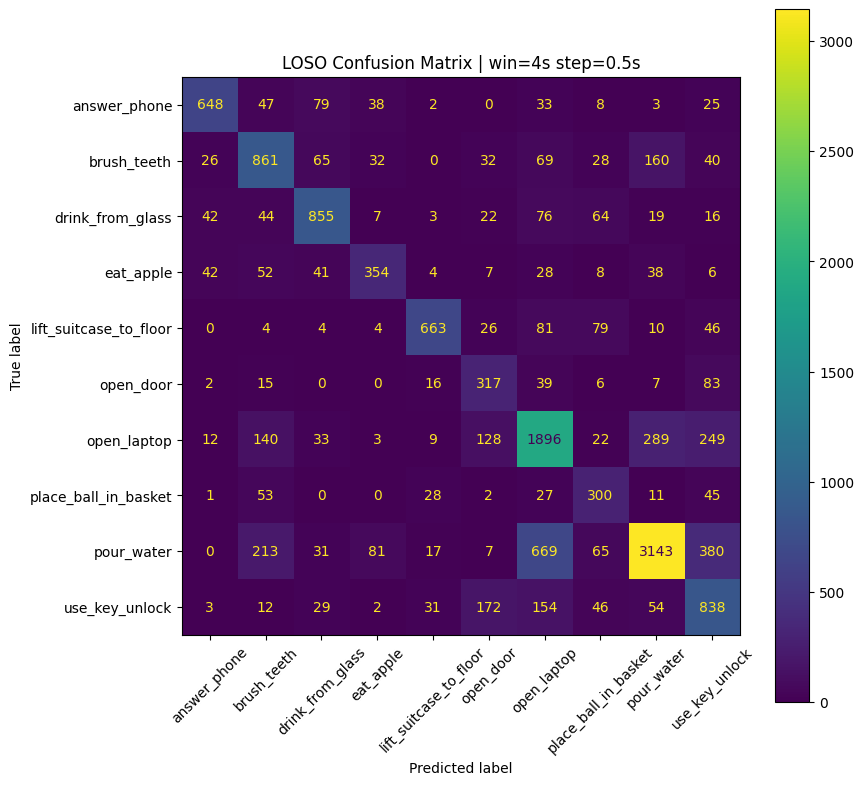

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-sensorOrientation__win-4s__step-0.5s__20260403_045247__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-sensorOrientation__win-4s__step-0.5s__20260403_045247__folds.csv

Channel LOO run 10/11
Left out: jointAngle
Using channels (10): ['orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 128) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_position_velocity_acceleration_angularVelocity_angularAcceleration_sensorFreeAcceleration_sensorMagneticField_sensorOrientation_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out jointAn

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,9,0.623703,0.582278,0.653432
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,17,0.667074,0.842105,0.839650
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.698839,0.936768,0.931350
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,11,0.654856,0.970803,0.825187
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,12,0.669517,0.835655,0.774749
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,8,0.687844,0.837719,0.821923
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.570556,0.960422,0.949717
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.637141,0.865672,0.784583
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,7,0.644166,0.112903,0.058883
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,10,0.426823,0.709091,0.614739



LOSO SUMMARY
Overall window-level accuracy: 0.6321
Overall window-level macro F1: 0.5880
Mean fold accuracy: 0.6710 ± 0.2710
Mean fold macro F1: 0.6396 ± 0.2724

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,11,0.654856,0.970803,0.825187
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.570556,0.960422,0.949717
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,11,0.473491,0.959135,0.946969
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,11,0.489437,0.943627,0.918140
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.698839,0.936768,0.931350
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,8,0.494131,0.870902,0.837634
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.637141,0.865672,0.784583
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,15,0.478286,0.851913,0.778074
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,17,0.667074,0.842105,0.839650
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,8,0.687844,0.837719,0.821923



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.726     0.612     0.664       883
           brush_teeth      0.766     0.494     0.600      1313
      drink_from_glass      0.719     0.627     0.670      1148
             eat_apple      0.470     0.607     0.530       580
lift_suitcase_to_floor      0.574     0.711     0.635       917
             open_door      0.329     0.662     0.439       485
           open_laptop      0.664     0.683     0.673      2781
  place_ball_in_basket      0.295     0.719     0.418       467
            pour_water      0.851     0.639     0.730      4606
        use_key_unlock      0.476     0.572     0.520      1341

              accuracy                          0.632     14521
             macro avg      0.587     0.633     0.588     14521
          weighted avg      0.687     0.632     0.646     14521



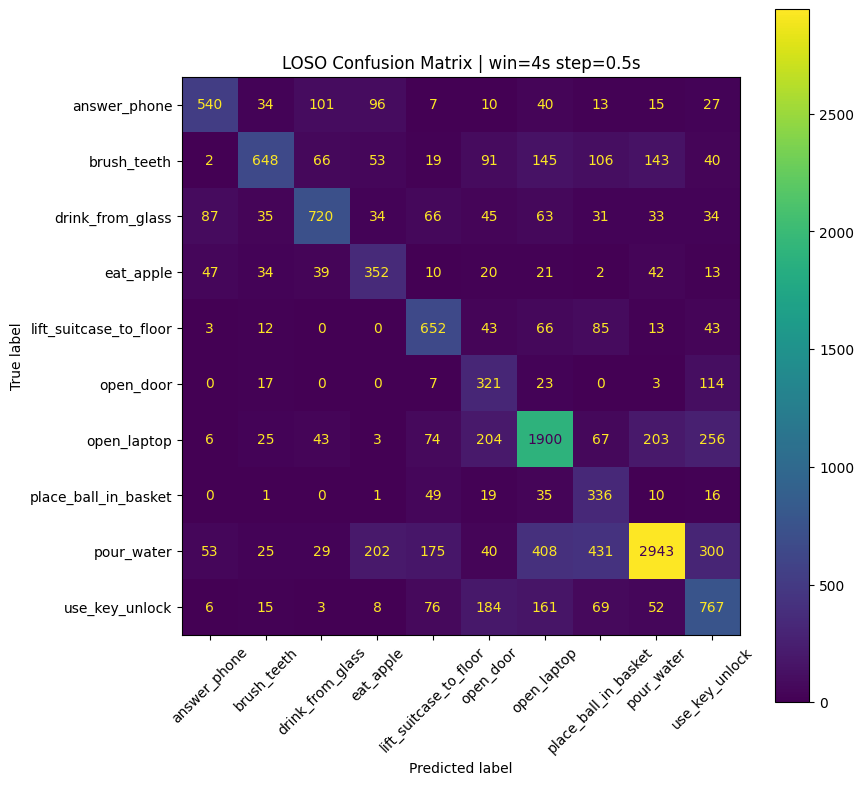

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-jointAngle__win-4s__step-0.5s__20260403_051910__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-jointAngle__win-4s__step-0.5s__20260403_051910__folds.csv

Channel LOO run 11/11
Left out: jointAngleXZY
Using channels (10): ['orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 128) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-orientation_position_velocity_acceleration_angularVelocity_angularAcceleration_sensorFreeAcceleration_sensorMagneticField_sensorOrientation_jointAngle__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel LOO (left out jointAngleXZY) dataset l

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,12,0.648142,0.665461,0.702559
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,12,0.619426,0.853383,0.750654
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,9,0.576970,0.861827,0.857426
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,10,0.656078,0.970803,0.914749
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,11,0.601100,0.807799,0.812149
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,7,0.563531,0.846491,0.838368
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,12,0.616066,0.973615,0.971678
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,12,0.646915,0.912313,0.902960
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,11,0.586133,0.198680,0.057232
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,8,0.397552,0.590909,0.456999



LOSO SUMMARY
Overall window-level accuracy: 0.6379
Overall window-level macro F1: 0.6107
Mean fold accuracy: 0.6737 ± 0.2812
Mean fold macro F1: 0.6515 ± 0.2900

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,12,0.616066,0.973615,0.971678
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,10,0.656078,0.970803,0.914749
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,19,0.579812,0.965686,0.955475
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,7,0.470364,0.961066,0.978960
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,12,0.646915,0.912313,0.902960
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,10,0.484448,0.873544,0.805273
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,9,0.576970,0.861827,0.857426
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,8,0.413877,0.860577,0.807924
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,12,0.619426,0.853383,0.750654
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,7,0.563531,0.846491,0.838368



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.719     0.717     0.718       883
           brush_teeth      0.471     0.633     0.540      1313
      drink_from_glass      0.667     0.692     0.679      1148
             eat_apple      0.642     0.597     0.618       580
lift_suitcase_to_floor      0.572     0.690     0.625       917
             open_door      0.479     0.713     0.573       485
           open_laptop      0.704     0.597     0.646      2781
  place_ball_in_basket      0.366     0.582     0.450       467
            pour_water      0.834     0.637     0.722      4606
        use_key_unlock      0.479     0.606     0.535      1341

              accuracy                          0.638     14521
             macro avg      0.593     0.646     0.611     14521
          weighted avg      0.672     0.638     0.646     14521



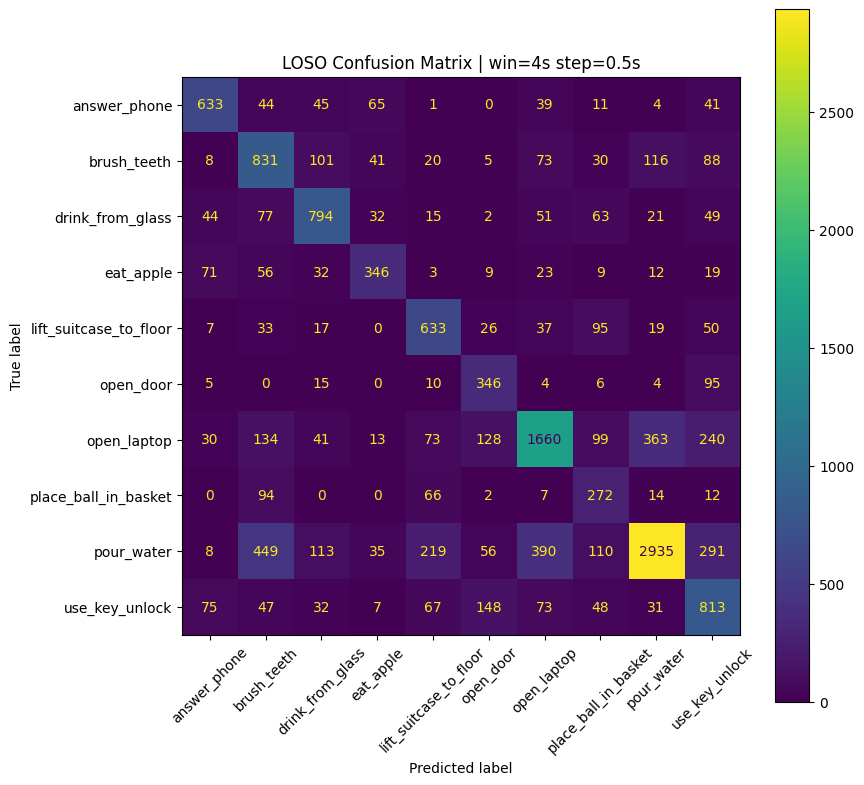

Saved summary CSV: experiment_results/channel_ablation__chloo__leftout-jointAngleXZY__win-4s__step-0.5s__20260403_054437__summary.csv
Saved per-fold CSV: experiment_results/channel_ablation__chloo__leftout-jointAngleXZY__win-4s__step-0.5s__20260403_054437__folds.csv


ValueError: Must pass 2-d input. shape=(11, 1, 21)

In [10]:
from sklearn.metrics import f1_score

def run_loso_experiment(
    X,
    y,
    groups,
    study_name: str,
    win_len_s: float,
    step_s: float,
    plot_first_fold_curves: bool = PLOT_FIRST_FOLD_CURVES,
    loso_max_folds = LOSO_MAX_FOLDS,
    save_per_fold_csv: bool = SAVE_PER_FOLD_CSV,
    results_dir: str = RESULTS_DIR,
):
    labels, lab2i, i2lab, y_i = encode_labels(y)
    all_loso_splits = build_loso_splits(X, y_i, groups, max_folds=loso_max_folds)

    print(f"Total LOSO folds to run: {len(all_loso_splits)}")
    print("Classes:", labels)
    print("Subjects:", sorted(np.unique(groups)))

    fold_rows = []
    all_y_true = []
    all_y_pred = []
    first_fold_history = None

    for fold_idx, (trainval_idx, test_idx) in enumerate(all_loso_splits, start=1):
        held_out_subject = np.unique(groups[test_idx])
        if len(held_out_subject) != 1:
            raise RuntimeError("LOSO fold should contain exactly one held-out subject.")
        held_out_subject = held_out_subject[0]

        print("=" * 90)
        print(f"LOSO fold {fold_idx}/{len(all_loso_splits)} | test subject: {held_out_subject}")

        # Outer split: one subject held out for test
        X_trainval_raw, X_test_raw = X[trainval_idx], X[test_idx]
        y_trainval_i, y_test_i = y_i[trainval_idx], y_i[test_idx]
        g_trainval, g_test = groups[trainval_idx], groups[test_idx]

        # Inner grouped split for validation (training subjects only)
        train_sub_idx, val_sub_idx = make_grouped_train_val_split(g_trainval, val_size=VAL_SIZE, random_state=RANDOM_STATE)

        X_train_raw, X_val_raw = X_trainval_raw[train_sub_idx], X_trainval_raw[val_sub_idx]
        y_train_i, y_val_i = y_trainval_i[train_sub_idx], y_trainval_i[val_sub_idx]
        g_train, g_val = g_trainval[train_sub_idx], g_trainval[val_sub_idx]

        print(f"Train subjects: {sorted(np.unique(g_train))}")
        print(f"Val subjects:   {sorted(np.unique(g_val))}")
        print(f"Test subject:   {sorted(np.unique(g_test))}")

        # Fit normalization on TRAIN ONLY, then apply to val/test
        mu, sd = fit_channel_zscore(X_train_raw)
        X_train = apply_channel_zscore(X_train_raw, mu, sd)
        X_val   = apply_channel_zscore(X_val_raw, mu, sd)
        X_test  = apply_channel_zscore(X_test_raw, mu, sd)

        # Leakage checks
        report_split_integrity("train", X_train, g_train, trainval_idx[train_sub_idx],
                            "val", X_val, g_val, trainval_idx[val_sub_idx])
        report_split_integrity("train", X_train, g_train, trainval_idx[train_sub_idx],
                            "test", X_test, g_test, test_idx)
        report_split_integrity("val", X_val, g_val, trainval_idx[val_sub_idx],
                            "test", X_test, g_test, test_idx)

        train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(
            X_train, y_train_i, X_val, y_val_i, X_test, y_test_i
        )

        model, criterion, optimizer = build_model_and_training_objects(
            in_channels=train_ds.X.shape[1],
            y_train_i=y_train_i,
        )

        train_losses, val_losses, test_losses = [], [], []
        train_accs, val_accs, test_accs = [], [], []

        epochs_ran = 0
        best_val_acc = -1.0
        best_state = None
        patience_counter = 0

        for epoch in range(1, EPOCHS + 1):
            epochs_ran = epoch
            model.train()
            total_loss = 0.0
            ys, ps = [], []

            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                total_loss += loss.item() * xb.size(0)
                pred = torch.argmax(logits, dim=1)
                ys.append(yb.cpu().numpy())
                ps.append(pred.detach().cpu().numpy())

            train_loss = total_loss / len(train_loader.dataset)
            train_acc = accuracy_score(np.concatenate(ys), np.concatenate(ps))

            val_loss, val_acc = run_eval_loss_acc(model, val_loader, criterion)
            test_loss, test_acc = run_eval_loss_acc(model, test_loader, criterion)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            test_losses.append(test_loss)

            train_accs.append(train_acc)
            val_accs.append(val_acc)
            test_accs.append(test_acc)

            print(
                f"Epoch {epoch:02d} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
                f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

            improvement = val_acc - best_val_acc
            if improvement > EARLY_STOPPING_MIN_DELTA:
                best_val_acc = val_acc
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                print(
                    f"  No validation improvement greater than {EARLY_STOPPING_MIN_DELTA:.4f}. "
                    f"Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}"
                )
                if patience_counter >= EARLY_STOPPING_PATIENCE:
                    print(f"Early stopping triggered at epoch {epoch}.")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        y_true_fold, y_pred_fold = eval_model(model, test_loader)

        fold_acc = accuracy_score(y_true_fold, y_pred_fold)
        fold_macro_f1 = f1_score(y_true_fold, y_pred_fold, average="macro", zero_division=0)

        fold_rows.append({
            "fold": fold_idx,
            "test_subject": held_out_subject,
            "win_len_s": win_len_s,
            "step_s": step_s,
            "overlap_fraction": window_overlap_fraction(win_len_s, step_s),
            "n_train_windows": len(train_ds),
            "n_val_windows": len(val_ds),
            "n_test_windows": len(test_ds),
            "n_train_subjects": len(np.unique(g_train)),
            "n_val_subjects": len(np.unique(g_val)),
            "epochs_ran": epochs_ran,
            "best_val_acc": best_val_acc,
            "test_acc": fold_acc,
            "test_macro_f1": fold_macro_f1,
        })

        all_y_true.append(y_true_fold)
        all_y_pred.append(y_pred_fold)

        print(f"Fold {fold_idx} complete | subject={held_out_subject} | "
            f"test_acc={fold_acc:.4f} | test_macro_f1={fold_macro_f1:.4f}")

        if first_fold_history is None:
            first_fold_history = {
                "epochs_ran": epochs_ran,
                "train_losses": train_losses.copy(),
                "val_losses": val_losses.copy(),
                "test_losses": test_losses.copy(),
                "train_accs": train_accs.copy(),
                "val_accs": val_accs.copy(),
                "test_accs": test_accs.copy(),
                "subject": held_out_subject,
            }

    results_df = pd.DataFrame(fold_rows)
    display(results_df)

    all_y_true = np.concatenate(all_y_true)
    all_y_pred = np.concatenate(all_y_pred)

    overall_acc = accuracy_score(all_y_true, all_y_pred)
    overall_macro_f1 = f1_score(all_y_true, all_y_pred, average="macro", zero_division=0)
    mean_fold_acc = results_df["test_acc"].mean()
    std_fold_acc = results_df["test_acc"].std(ddof=1) if len(results_df) > 1 else 0.0
    mean_fold_macro_f1 = results_df["test_macro_f1"].mean()
    std_fold_macro_f1 = results_df["test_macro_f1"].std(ddof=1) if len(results_df) > 1 else 0.0
    mean_epochs_ran = results_df["epochs_ran"].mean()
    mean_best_val_acc = results_df["best_val_acc"].mean()

    print("\n" + "=" * 90)
    print("LOSO SUMMARY")
    print(f"Overall window-level accuracy: {overall_acc:.4f}")
    print(f"Overall window-level macro F1: {overall_macro_f1:.4f}")
    print(f"Mean fold accuracy: {mean_fold_acc:.4f} ± {std_fold_acc:.4f}")
    print(f"Mean fold macro F1: {mean_fold_macro_f1:.4f} ± {std_fold_macro_f1:.4f}")

    print("\nPer-fold results:")
    display(results_df.sort_values("test_acc", ascending=False))

    print("\nClassification report across all LOSO test folds:")
    print(classification_report(all_y_true, all_y_pred, target_names=labels, digits=3, zero_division=0))

    cm = confusion_matrix(all_y_true, all_y_pred, labels=list(range(len(labels))))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(9, 9))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title(f"LOSO Confusion Matrix | win={win_len_s:g}s step={step_s:g}s")
    plt.show()

    if plot_first_fold_curves and first_fold_history is not None:
        epochs = range(1, first_fold_history["epochs_ran"] + 1)

        plt.figure(figsize=(7, 5))
        plt.plot(epochs, first_fold_history["train_losses"], label="Train loss")
        plt.plot(epochs, first_fold_history["val_losses"], label="Val loss")
        plt.plot(epochs, first_fold_history["test_losses"], label="Test loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"TCN Loss vs Epoch | First LOSO fold ({first_fold_history['subject']})")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.plot(epochs, first_fold_history["train_accs"], label="Train acc")
        plt.plot(epochs, first_fold_history["val_accs"], label="Val acc")
        plt.plot(epochs, first_fold_history["test_accs"], label="Test acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"TCN Accuracy vs Epoch | First LOSO fold ({first_fold_history['subject']})")
        plt.legend()
        plt.grid(True)
        plt.show()

    results_stem = make_results_stem(study_name=study_name, win_len_s=win_len_s, step_s=step_s, results_dir=results_dir)
    summary_row = pd.DataFrame([{
        "study_name": study_name,
        "win_len_s": win_len_s,
        "step_s": step_s,
        "overlap_fraction": window_overlap_fraction(win_len_s, step_s),
        "n_total_windows": len(y),
        "n_subjects": len(np.unique(groups)),
        "n_classes": len(labels),
        "cache_path": make_dataset_cache_path(DATA_ROOT, CHANNELS, win_len_s, step_s, ALLOWED_TASKS, CACHE_DIR),
        "loso_folds_ran": len(results_df),
        "overall_acc": overall_acc,
        "overall_macro_f1": overall_macro_f1,
        "mean_fold_acc": mean_fold_acc,
        "std_fold_acc": std_fold_acc,
        "mean_fold_macro_f1": mean_fold_macro_f1,
        "std_fold_macro_f1": std_fold_macro_f1,
        "mean_epochs_ran": mean_epochs_ran,
        "mean_best_val_acc": mean_best_val_acc,
    }])

    summary_csv = results_stem + "__summary.csv"
    folds_csv = results_stem + "__folds.csv"
    summary_row.to_csv(summary_csv, index=False)
    if save_per_fold_csv:
        results_df.to_csv(folds_csv, index=False)

    print(f"Saved summary CSV: {summary_csv}")
    if save_per_fold_csv:
        print(f"Saved per-fold CSV: {folds_csv}")

    return {
        "summary_row": summary_row,
        "fold_results": results_df,
        "all_y_true": all_y_true,
        "all_y_pred": all_y_pred,
        "summary_csv": summary_csv,
        "folds_csv": folds_csv if save_per_fold_csv else None,
    }


def run_single_fixed_channel_baseline(
    study_name: str = None,
    channels = None,
    win_len_s: float = WIN_LEN_S,
    step_s: float = STEP_S,
    use_dataset_cache: bool = USE_DATASET_CACHE,
    force_rebuild_dataset: bool = FORCE_REBUILD_DATASET,
    loso_max_folds = LOSO_MAX_FOLDS,
):
    if channels is None:
        channels = CHANNELS

    if study_name is None:
        study_name = (
            f"{RESULTS_BASENAME}"
            f"__all11_baseline"
            f"__win-{win_len_s:g}s"
            f"__step-{step_s:g}s"
            f"__ch-{_safe_name('_'.join(channels))}"
        )

    print("\n" + "#" * 100)
    print("RUNNING SINGLE FIXED CHANNEL BASELINE")
    print(f"Study name: {study_name}")
    print(f"Window length: {win_len_s:g}s")
    print(f"Step size: {step_s:g}s")
    print(f"Channels ({len(channels)}): {channels}")

    X, y, groups, dataset_cache_path = load_or_build_dataset(
        DATA_ROOT,
        win_len_s=win_len_s,
        step_s=step_s,
        channels=channels,
        use_cache=use_dataset_cache,
        force_rebuild=force_rebuild_dataset,
    )
    summarize_dataset(X, y, groups, prefix="Fixed all-channel baseline")

    run_out = run_loso_experiment(
        X=X,
        y=y,
        groups=groups,
        study_name=study_name,
        win_len_s=win_len_s,
        step_s=step_s,
        plot_first_fold_curves=PLOT_FIRST_FOLD_CURVES,
        loso_max_folds=loso_max_folds,
        save_per_fold_csv=SAVE_PER_FOLD_CSV,
        results_dir=RESULTS_DIR,
    )

    summary_row = run_out["summary_row"].copy()
    summary_row["dataset_cache_path"] = dataset_cache_path
    display(summary_row)

    print(f"Dataset cache path: {dataset_cache_path}")
    print(f"Summary CSV: {run_out['summary_csv']}")
    if run_out.get("folds_csv") is not None:
        print(f"Per-fold CSV: {run_out['folds_csv']}")

    return run_out



def run_channel_leave_one_out_sweep(
    full_channels = None,
    win_len_s: float = WIN_LEN_S,
    step_s: float = STEP_S,
    use_dataset_cache: bool = USE_DATASET_CACHE,
    force_rebuild_dataset: bool = FORCE_REBUILD_DATASET,
    loso_max_folds = LOSO_MAX_FOLDS,
    results_dir: str = RESULTS_DIR,
):
    """
    Run 11 leave-one-channel-out experiments from the full channel list.
    Each run uses 10 channels, leaving exactly one out.
    """
    if full_channels is None:
        full_channels = CHANNELS

    if len(full_channels) < 2:
        raise ValueError("Need at least 2 channels for leave-one-out sweep.")

    print("\n" + "#" * 100)
    print("RUNNING CHANNEL LEAVE-ONE-OUT SWEEP")
    print(f"Fixed window length: {win_len_s:g}s")
    print(f"Fixed step size: {step_s:g}s")
    print(f"Full channel list ({len(full_channels)}): {full_channels}")

    sweep_rows = []
    sweep_outputs = {}

    for run_idx, left_out_channel in enumerate(full_channels, start=1):
        channels_this_run = [ch for ch in full_channels if ch != left_out_channel]

        study_name = (
            f"{RESULTS_BASENAME}"
            f"__chloo"
            f"__leftout-{_safe_name(left_out_channel)}"
        )

        print("\n" + "=" * 100)
        print(f"Channel LOO run {run_idx}/{len(full_channels)}")
        print(f"Left out: {left_out_channel}")
        print(f"Using channels ({len(channels_this_run)}): {channels_this_run}")

        X, y, groups, dataset_cache_path = load_or_build_dataset(
            DATA_ROOT,
            win_len_s=win_len_s,
            step_s=step_s,
            channels=channels_this_run,
            use_cache=use_dataset_cache,
            force_rebuild=force_rebuild_dataset,
        )
        summarize_dataset(
            X, y, groups,
            prefix=f"Channel LOO (left out {left_out_channel})"
        )

        run_out = run_loso_experiment(
            X=X,
            y=y,
            groups=groups,
            study_name=study_name,
            win_len_s=win_len_s,
            step_s=step_s,
            plot_first_fold_curves=False,
            loso_max_folds=loso_max_folds,
            save_per_fold_csv=SAVE_PER_FOLD_CSV,
            results_dir=results_dir,
        )

        summary_row = run_out["summary_row"].copy()
        summary_row["left_out_channel"] = left_out_channel
        summary_row["channels_used"] = "|".join(channels_this_run)
        summary_row["n_channels_used"] = len(channels_this_run)
        summary_row["dataset_cache_path"] = dataset_cache_path

        sweep_rows.append(summary_row)
        sweep_outputs[left_out_channel] = {
            "channels_used": channels_this_run,
            "dataset_cache_path": dataset_cache_path,
            "run_out": run_out,
        }

    sweep_df = pd.DataFrame(sweep_rows)

    if "macro_f1" in sweep_df.columns:
        sweep_df = sweep_df.sort_values(
            by=["macro_f1", "accuracy"],
            ascending=[False, False]
        ).reset_index(drop=True)

    os.makedirs(results_dir, exist_ok=True)
    sweep_csv = os.path.join(
        results_dir,
        (
            f"{RESULTS_BASENAME}"
            f"__channel_leave_one_out_summary"
            f"__win-{win_len_s:g}s"
            f"__step-{step_s:g}s.csv"
        )
    )
    sweep_df.to_csv(sweep_csv, index=False)

    print("\n" + "#" * 100)
    print("CHANNEL LEAVE-ONE-OUT SWEEP COMPLETE")
    print(f"Saved sweep summary CSV: {sweep_csv}")
    display(sweep_df)

    return sweep_df, sweep_outputs, sweep_csv


# Run the fixed 11x leave-one-channel-out sweep once.
channel_loo_results_df, channel_loo_outputs, channel_loo_csv = run_channel_leave_one_out_sweep()

print("\nChannel leave-one-out sweep complete.")
display(channel_loo_results_df)
